# Financial Fraud Detection - SageMaker Endpoint Testing

This notebook tests the deployed SageMaker endpoint running NVIDIA's GNN-based fraud detection model.

**The Model:**
A Graph Neural Network that predicts whether financial transactions are fraudulent by analyzing the bipartite graph of users (card holders) and merchants, where transactions are edges connecting them.

**Input Features:**
- `x_user` (num_users, 13): User/card features (binary-encoded card ID)
- `x_merchant` (num_merchants, 24): Merchant features (encoded merchant name + MCC code)
- `edge_index_user_to_merchant` (2, num_transactions): Graph connectivity
- `edge_attr_user_to_merchant` (num_transactions, 38): Transaction features (amount, location, etc.)

**Output:**
- `PREDICTION` (num_transactions, 1): Fraud probability (0=legit, 1=fraud)

## Configuration

In [60]:
# Configuration - UPDATE THESE VALUES
ENDPOINT_NAME = "fraud-detection-endpoint-v2"
AWS_REGION = "us-east-1"
AWS_PROFILE = "Admin-Account-Access-541765610078"  # Set to None to use default credentials
S3_BUCKET = "fraud-detection-541765610078-sm"  # Bucket with preprocessed test data

# Test parameters
MAX_TRANSACTIONS = None  # Set to None to use entire test set (25,803 transactions)
FRAUD_THRESHOLD = 0.5   # Decision threshold for fraud classification

In [61]:
import io
import json
import time

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# Feature dimensions from TabFormer preprocessing
USER_FEATURE_DIM = 13
MERCHANT_FEATURE_DIM = 24
EDGE_FEATURE_DIM = 38
TEST_DATA_PREFIX = "data/processed/gnn/test_gnn"

In [62]:
# Create AWS clients
session_kwargs = {"region_name": AWS_REGION}
if AWS_PROFILE:
    session_kwargs["profile_name"] = AWS_PROFILE

session = boto3.Session(**session_kwargs)
sm_client = session.client("sagemaker")
runtime = session.client("sagemaker-runtime")
s3_client = session.client("s3")

print(f"Region: {AWS_REGION}")
print(f"Profile: {AWS_PROFILE or 'default'}")
print(f"Endpoint: {ENDPOINT_NAME}")

Region: us-east-1
Profile: Admin-Account-Access-541765610078
Endpoint: fraud-detection-endpoint-v2


## Helper Functions

In [63]:
def load_test_data_from_s3(bucket, max_transactions=None, filter_nodes=True):
    """
    Load preprocessed test data from S3.
    
    Args:
        bucket: S3 bucket name
        max_transactions: Limit number of transactions (for faster testing)
        filter_nodes: Only include nodes involved in sampled transactions
    
    Returns:
        data: dict with model inputs
        labels: ground truth fraud labels
    """
    def read_csv(key):
        response = s3_client.get_object(Bucket=bucket, Key=key)
        return pd.read_csv(io.BytesIO(response["Body"].read()))
    
    def read_mask(key):
        try:
            response = s3_client.get_object(Bucket=bucket, Key=key)
            return pd.read_csv(io.BytesIO(response["Body"].read()), header=None).values.ravel().astype(np.int32)
        except:
            return None

    print("Loading test data from S3...")
    
    # Load all data
    user_df = read_csv(f"{TEST_DATA_PREFIX}/nodes/user.csv")
    merchant_df = read_csv(f"{TEST_DATA_PREFIX}/nodes/merchant.csv")
    edge_index_df = read_csv(f"{TEST_DATA_PREFIX}/edges/user_to_merchant.csv")
    edge_attr_df = read_csv(f"{TEST_DATA_PREFIX}/edges/user_to_merchant_attr.csv")
    edge_label_df = read_csv(f"{TEST_DATA_PREFIX}/edges/user_to_merchant_label.csv")
    
    user_mask = read_mask(f"{TEST_DATA_PREFIX}/nodes/user_feature_mask.csv")
    merchant_mask = read_mask(f"{TEST_DATA_PREFIX}/nodes/merchant_feature_mask.csv")
    edge_mask = read_mask(f"{TEST_DATA_PREFIX}/edges/user_to_merchant_feature_mask.csv")
    
    print(f"  Full dataset: {len(user_df)} users, {len(merchant_df)} merchants, {len(edge_attr_df)} transactions")
    
    # Subsample transactions
    num_transactions = len(edge_attr_df)
    if max_transactions and max_transactions < num_transactions:
        indices = np.random.choice(num_transactions, max_transactions, replace=False)
        indices = np.sort(indices)
        edge_index_df = edge_index_df.iloc[indices]
        edge_attr_df = edge_attr_df.iloc[indices]
        edge_label_df = edge_label_df.iloc[indices]
        num_transactions = max_transactions
    
    # Filter nodes to reduce payload size
    if filter_nodes and max_transactions:
        user_ids = edge_index_df.iloc[:, 0].unique()
        merchant_ids = edge_index_df.iloc[:, 1].unique()
        
        user_id_map = {old: new for new, old in enumerate(sorted(user_ids))}
        merchant_id_map = {old: new for new, old in enumerate(sorted(merchant_ids))}
        
        user_df = user_df.iloc[user_ids]
        merchant_df = merchant_df.iloc[merchant_ids]
        
        edge_index_df = edge_index_df.copy()
        edge_index_df.iloc[:, 0] = edge_index_df.iloc[:, 0].map(user_id_map)
        edge_index_df.iloc[:, 1] = edge_index_df.iloc[:, 1].map(merchant_id_map)
    
    # Build data dict
    data = {
        "x_user": user_df.values.astype(np.float32),
        "x_merchant": merchant_df.values.astype(np.float32),
        "edge_index_user_to_merchant": edge_index_df.values.T.astype(np.int64),
        "edge_attr_user_to_merchant": edge_attr_df.values.astype(np.float32),
        "COMPUTE_SHAP": np.array([False], dtype=np.bool_),
        "feature_mask_user": user_mask if user_mask is not None else np.zeros(user_df.shape[1], dtype=np.int32),
        "feature_mask_merchant": merchant_mask if merchant_mask is not None else np.zeros(merchant_df.shape[1], dtype=np.int32),
        "edge_feature_mask_user_to_merchant": edge_mask if edge_mask is not None else np.zeros(edge_attr_df.shape[1], dtype=np.int32),
    }
    
    labels = edge_label_df.values.ravel().astype(np.int32)
    
    print(f"  Sampled: {data['x_user'].shape[0]} users, {data['x_merchant'].shape[0]} merchants, {num_transactions} transactions")
    print(f"  Fraud rate: {labels.sum()}/{len(labels)} ({labels.sum()/len(labels)*100:.1f}%)")
    
    return data, labels

In [64]:
def numpy_to_triton_inputs(data):
    """Convert numpy arrays to Triton request format."""
    dtype_map = {
        np.float32: "FP32",
        np.int32: "INT32",
        np.int64: "INT64",
        np.bool_: "BOOL",
    }
    return [
        {
            "name": name,
            "shape": list(arr.shape),
            "datatype": dtype_map.get(arr.dtype.type, "FP32"),
            "data": arr.flatten().tolist(),
        }
        for name, arr in data.items()
    ]


def invoke_endpoint(data, compute_shap=False):
    """Send inference request to SageMaker endpoint."""
    data = data.copy()
    data["COMPUTE_SHAP"] = np.array([compute_shap], dtype=np.bool_)
    
    outputs = [{"name": "PREDICTION"}]
    if compute_shap:
        outputs.extend([
            {"name": "shap_values_merchant"},
            {"name": "shap_values_user"},
            {"name": "shap_values_user_to_merchant"},
        ])
    
    response = runtime.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Body=json.dumps({"inputs": numpy_to_triton_inputs(data), "outputs": outputs}),
    )
    return json.loads(response["Body"].read().decode())


def parse_response(response):
    """Parse Triton response into numpy arrays."""
    return {
        output["name"]: np.array(output["data"]).reshape(output["shape"])
        for output in response.get("outputs", [])
    }

## 1. Endpoint Health Check

In [65]:
endpoint_info = sm_client.describe_endpoint(EndpointName=ENDPOINT_NAME)
print(f"Endpoint: {ENDPOINT_NAME}")
print(f"Status: {endpoint_info['EndpointStatus']}")
print(f"Creation Time: {endpoint_info['CreationTime']}")

Endpoint: fraud-detection-endpoint-v2
Status: InService
Creation Time: 2026-03-01 16:59:03.698000+01:00


## 2. Load Real Test Data from S3

In [66]:
# Load preprocessed test data
test_data, labels = load_test_data_from_s3(S3_BUCKET, max_transactions=MAX_TRANSACTIONS)

Loading test data from S3...
  Full dataset: 4795 users, 6773 merchants, 25803 transactions
  Sampled: 4795 users, 6773 merchants, 25803 transactions
  Fraud rate: 2087/25803 (8.1%)


In [67]:
# Visualize the graph structure
print("\nGraph Structure:")
print(f"  Users (card holders): {test_data['x_user'].shape}")
print(f"  Merchants: {test_data['x_merchant'].shape}")
print(f"  Transactions (edges): {test_data['edge_attr_user_to_merchant'].shape}")
print(f"  Edge index shape: {test_data['edge_index_user_to_merchant'].shape}")


Graph Structure:
  Users (card holders): (4795, 13)
  Merchants: (6773, 24)
  Transactions (edges): (25803, 38)
  Edge index shape: (2, 25803)


## 3. Run Inference

In [68]:
print("Running inference...")
start = time.time()
response = invoke_endpoint(test_data, compute_shap=False)
elapsed = time.time() - start

result = parse_response(response)
predictions = result["PREDICTION"].flatten()

print(f"Inference time: {elapsed:.2f}s")
print(f"Throughput: {len(predictions)/elapsed:.0f} transactions/sec")
print(f"Predictions shape: {predictions.shape}")

Running inference...
Inference time: 2.32s
Throughput: 11134 transactions/sec
Predictions shape: (25803,)


## 4. Evaluate Model Performance

In [69]:
# Compute metrics at the configured threshold
y_pred = (predictions > FRAUD_THRESHOLD).astype(int)

accuracy = accuracy_score(labels, y_pred)
precision = precision_score(labels, y_pred, zero_division=0)
recall = recall_score(labels, y_pred, zero_division=0)
f1 = f1_score(labels, y_pred, zero_division=0)

print(f"\nModel Performance (threshold={FRAUD_THRESHOLD})")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Model Performance (threshold=0.5)
Accuracy:  0.9932
Precision: 0.9544
Recall:    0.9617
F1 Score:  0.9580


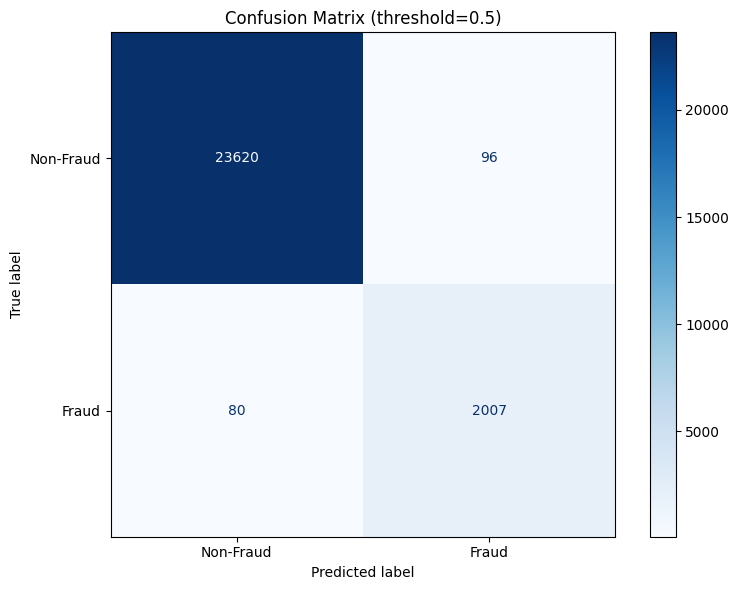


True Negatives (correct legit): 23620
False Positives (flagged legit): 96
False Negatives (missed fraud): 80
True Positives (caught fraud): 2007


In [70]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix (threshold={FRAUD_THRESHOLD})")
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (correct legit): {cm[0,0]}")
print(f"False Positives (flagged legit): {cm[0,1]}")
print(f"False Negatives (missed fraud): {cm[1,0]}")
print(f"True Positives (caught fraud): {cm[1,1]}")

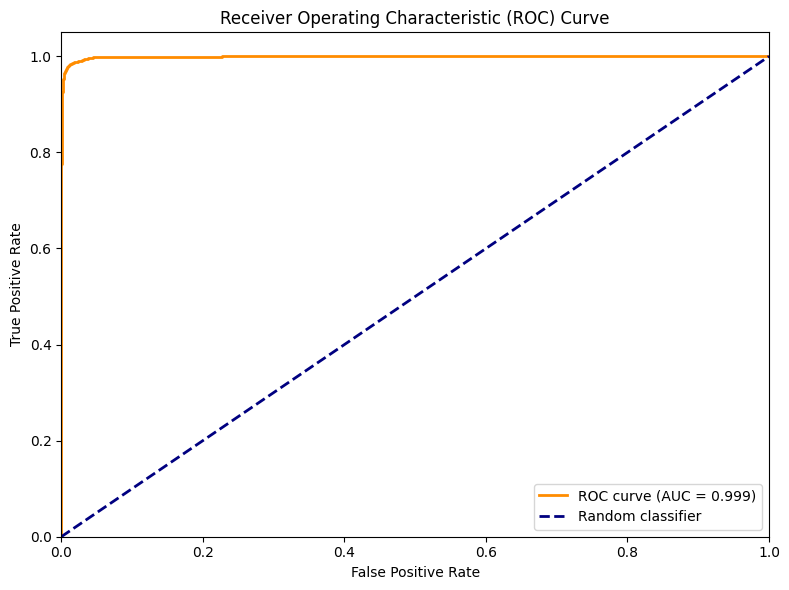

AUC: 0.9990


In [71]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(labels, predictions)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")

/var/folders/18/6zz0z63s12gbjtyl63hmhf800000gn/T/ipykernel_56121/1386436134.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit_preds, fraud_preds], labels=['Non-Fraud', 'Fraud'])


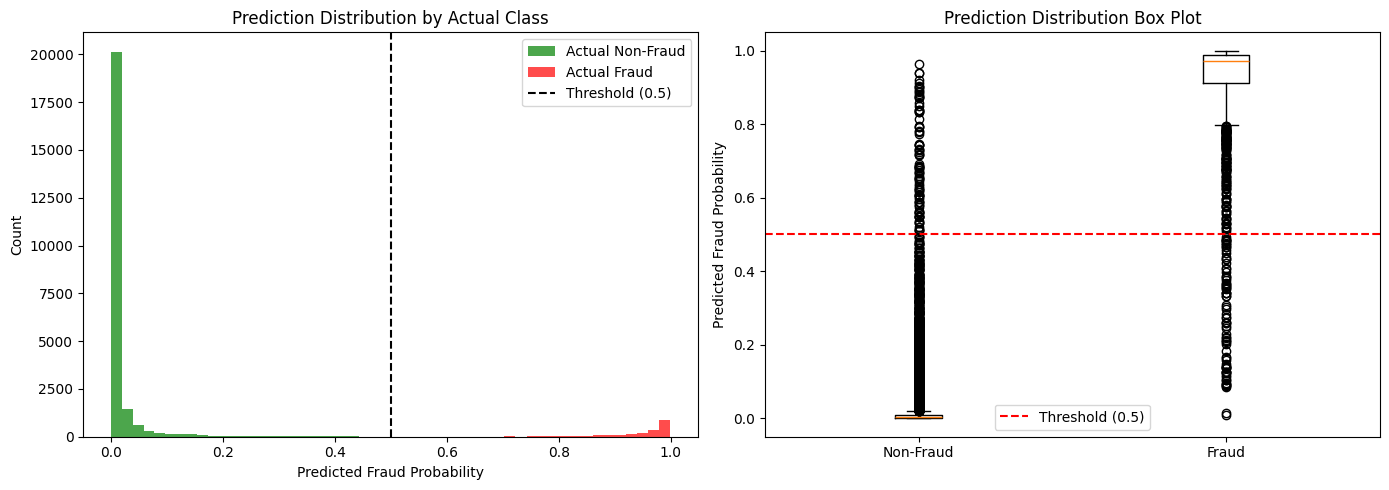

In [72]:
# Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by actual class
axes[0].hist(predictions[labels == 0], bins=50, alpha=0.7, label='Actual Non-Fraud', color='green')
axes[0].hist(predictions[labels == 1], bins=50, alpha=0.7, label='Actual Fraud', color='red')
axes[0].axvline(x=FRAUD_THRESHOLD, color='black', linestyle='--', label=f'Threshold ({FRAUD_THRESHOLD})')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Distribution by Actual Class')
axes[0].legend()

# Box plot
fraud_preds = predictions[labels == 1]
legit_preds = predictions[labels == 0]
axes[1].boxplot([legit_preds, fraud_preds], labels=['Non-Fraud', 'Fraud'])
axes[1].axhline(y=FRAUD_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({FRAUD_THRESHOLD})')
axes[1].set_ylabel('Predicted Fraud Probability')
axes[1].set_title('Prediction Distribution Box Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sample Predictions

In [73]:
# Create a dataframe with predictions
results_df = pd.DataFrame({
    'user_id': test_data['edge_index_user_to_merchant'][0],
    'merchant_id': test_data['edge_index_user_to_merchant'][1],
    'actual': labels,
    'predicted_prob': predictions,
    'predicted_class': y_pred,
})
results_df['correct'] = results_df['actual'] == results_df['predicted_class']
results_df['actual_label'] = results_df['actual'].map({0: 'Non-Fraud', 1: 'Fraud'})
results_df['predicted_label'] = results_df['predicted_class'].map({0: 'Non-Fraud', 1: 'Fraud'})

print(f"Total transactions: {len(results_df)}")
print(f"Correct predictions: {results_df['correct'].sum()} ({results_df['correct'].mean()*100:.1f}%)")

Total transactions: 25803
Correct predictions: 25627 (99.3%)


In [74]:
# Show correctly identified fraud
print("\n=== Correctly Identified Fraud (True Positives) ===")
true_positives = results_df[(results_df['actual'] == 1) & (results_df['predicted_class'] == 1)]
print(f"Count: {len(true_positives)}")
if len(true_positives) > 0:
    display(true_positives.head(10)[['user_id', 'merchant_id', 'predicted_prob', 'actual_label']])


=== Correctly Identified Fraud (True Positives) ===
Count: 2007


,user_id,merchant_id,predicted_prob,actual_label
1,1,1,0.971740,Fraud
7,7,7,0.998472,Fraud
8,8,8,0.893297,Fraud
9,9,9,0.907832,Fraud
23,23,22,0.933919,Fraud
24,24,23,0.941512,Fraud
68,66,23,0.982454,Fraud
72,70,64,0.969427,Fraud
86,84,72,0.975797,Fraud
103,7,23,0.992643,Fraud


In [75]:
# Show missed fraud
print("\n=== Missed Fraud (False Negatives) ===")
false_negatives = results_df[(results_df['actual'] == 1) & (results_df['predicted_class'] == 0)]
print(f"Count: {len(false_negatives)}")
if len(false_negatives) > 0:
    display(false_negatives.head(10)[['user_id', 'merchant_id', 'predicted_prob', 'actual_label']])


=== Missed Fraud (False Negatives) ===
Count: 80


,user_id,merchant_id,predicted_prob,actual_label
125,121,8,0.258431,Fraud
524,486,24,0.340648,Fraud
1120,121,39,0.439947,Fraud
3075,2072,72,0.271622,Fraud
3548,464,440,0.141801,Fraud
3930,486,108,0.433381,Fraud
4306,636,40,0.126928,Fraud
4400,121,64,0.302045,Fraud
4785,24,440,0.111230,Fraud
4849,462,244,0.384392,Fraud


In [76]:
# Create a small test case for Shapley computation (expensive operation)
def make_synthetic_data(num_merchants=2, num_users=3, num_transactions=1):
    # Generate random edges between users and merchants
    user_indices = np.random.randint(0, num_users, size=num_transactions)
    merchant_indices = np.random.randint(0, num_merchants, size=num_transactions)
    
    return {
        "x_user": np.random.randn(num_users, USER_FEATURE_DIM).astype(np.float32),
        "x_merchant": np.random.randn(num_merchants, MERCHANT_FEATURE_DIM).astype(np.float32),
        "edge_index_user_to_merchant": np.array([user_indices, merchant_indices], dtype=np.int64),
        "edge_attr_user_to_merchant": np.random.randn(num_transactions, EDGE_FEATURE_DIM).astype(np.float32),
        "COMPUTE_SHAP": np.array([True], dtype=np.bool_),
        "feature_mask_user": np.zeros(USER_FEATURE_DIM, dtype=np.int32),
        "feature_mask_merchant": np.zeros(MERCHANT_FEATURE_DIM, dtype=np.int32),
        "edge_feature_mask_user_to_merchant": np.zeros(EDGE_FEATURE_DIM, dtype=np.int32),
    }

shap_data = make_synthetic_data()

## 6. Threshold Analysis

Explore how different thresholds affect precision and recall.

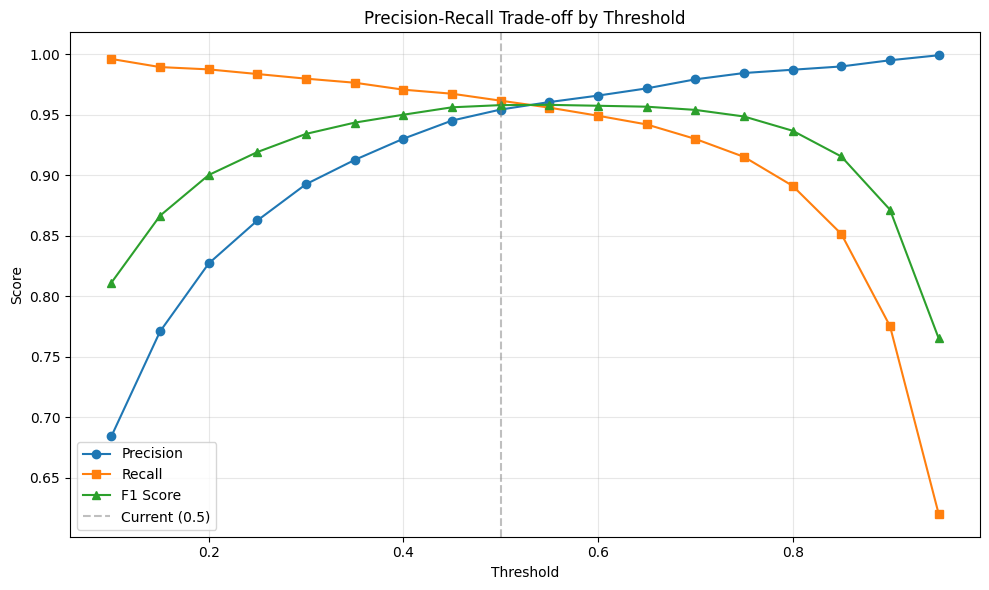


Optimal threshold for F1: 0.55
  Precision: 0.9605
  Recall: 0.9559
  F1: 0.9582


In [77]:
# Compute metrics at different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)
metrics_by_threshold = []

for thresh in thresholds:
    y_pred_t = (predictions > thresh).astype(int)
    metrics_by_threshold.append({
        'threshold': thresh,
        'precision': precision_score(labels, y_pred_t, zero_division=0),
        'recall': recall_score(labels, y_pred_t, zero_division=0),
        'f1': f1_score(labels, y_pred_t, zero_division=0),
        'accuracy': accuracy_score(labels, y_pred_t),
    })

threshold_df = pd.DataFrame(metrics_by_threshold)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='o')
ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='s')
ax.plot(threshold_df['threshold'], threshold_df['f1'], label='F1 Score', marker='^')
ax.axvline(x=FRAUD_THRESHOLD, color='gray', linestyle='--', alpha=0.5, label=f'Current ({FRAUD_THRESHOLD})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall Trade-off by Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal threshold for F1
best_idx = threshold_df['f1'].idxmax()
best_thresh = threshold_df.loc[best_idx, 'threshold']
print(f"\nOptimal threshold for F1: {best_thresh:.2f}")
print(f"  Precision: {threshold_df.loc[best_idx, 'precision']:.4f}")
print(f"  Recall: {threshold_df.loc[best_idx, 'recall']:.4f}")
print(f"  F1: {threshold_df.loc[best_idx, 'f1']:.4f}")

## 7. Shapley Values (Explainability)

Compute Shapley values to understand which features contributed to a prediction.

In [78]:
# Create a small test case for Shapley computation (expensive operation)
def make_synthetic_data(num_merchants=2, num_users=3, num_transactions=1):
    return {
        "x_user": np.random.randn(num_users, USER_FEATURE_DIM).astype(np.float32),
        "x_merchant": np.random.randn(num_merchants, MERCHANT_FEATURE_DIM).astype(np.float32),
        "edge_index_user_to_merchant": np.array([[0], [0]], dtype=np.int64),
        "edge_attr_user_to_merchant": np.random.randn(num_transactions, EDGE_FEATURE_DIM).astype(np.float32),
        "COMPUTE_SHAP": np.array([True], dtype=np.bool_),
        "feature_mask_user": np.zeros(USER_FEATURE_DIM, dtype=np.int32),
        "feature_mask_merchant": np.zeros(MERCHANT_FEATURE_DIM, dtype=np.int32),
        "edge_feature_mask_user_to_merchant": np.zeros(EDGE_FEATURE_DIM, dtype=np.int32),
    }

shap_data = make_synthetic_data()

In [79]:
print("Computing Shapley values (this may take a moment)...")
shap_response = invoke_endpoint(shap_data, compute_shap=True)
shap_result = parse_response(shap_response)

print("\nShapley Value Results:")
print("=" * 40)
for name, arr in shap_result.items():
    if name == "PREDICTION":
        prob = arr.flatten()[0]
        label = "FRAUD" if prob > 0.5 else "LEGIT"
        print(f"{name}: {prob:.4f} ({label})")
    else:
        print(f"{name}: shape={arr.shape}, sum={arr.sum():.4f}")

Computing Shapley values (this may take a moment)...

Shapley Value Results:
PREDICTION: 0.0319 (LEGIT)
shap_values_merchant: shape=(1,), sum=0.6505
shap_values_user: shape=(1,), sum=0.3523
shap_values_user_to_merchant: shape=(1,), sum=1.0299


## 8. Latency Benchmark

In [80]:
# Benchmark with synthetic data
benchmark_data = make_synthetic_data(num_merchants=5, num_users=7, num_transactions=1)
num_requests = 100
latencies = []

print(f"Running {num_requests} inference requests...")
for i in range(num_requests):
    start = time.time()
    invoke_endpoint(benchmark_data, compute_shap=False)
    latencies.append((time.time() - start) * 1000)

print(f"\nLatency Statistics:")
print(f"  Mean:  {np.mean(latencies):.0f} ms")
print(f"  Std:   {np.std(latencies):.0f} ms")
print(f"  Min:   {np.min(latencies):.0f} ms")
print(f"  Max:   {np.max(latencies):.0f} ms")
print(f"  P50:   {np.percentile(latencies, 50):.0f} ms")
print(f"  P95:   {np.percentile(latencies, 95):.0f} ms")
print(f"  P99:   {np.percentile(latencies, 99):.0f} ms")

Running 100 inference requests...

Latency Statistics:
  Mean:  103 ms
  Std:   2 ms
  Min:   101 ms
  Max:   111 ms
  P50:   103 ms
  P95:   106 ms
  P99:   111 ms


## Cleanup

Don't forget to delete the endpoint when done to avoid charges:

```bash
make clean-endpoints ENDPOINT_NAME=fraud-detection-endpoint
```